In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title="Image"):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

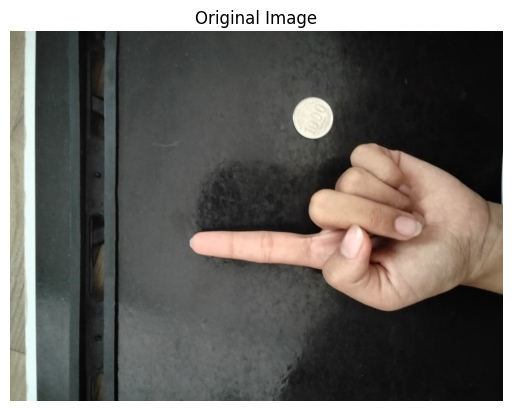

In [ ]:
image_path = "sample/sample1_best.jpeg"  # ganti sesuai file kamu

img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

show(img_rgb, "Original Image")

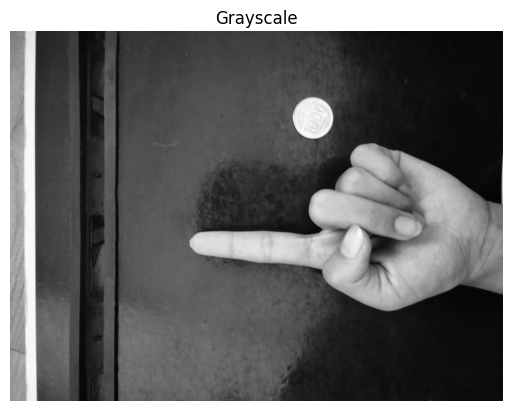

In [3]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

show(gray, "Grayscale")

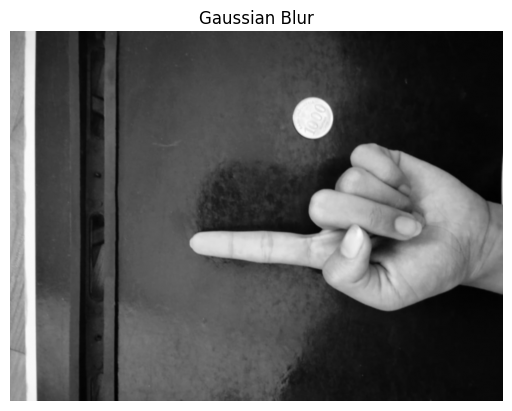

In [4]:
blur = cv2.GaussianBlur(gray, (5, 5), 0)

show(blur, "Gaussian Blur")

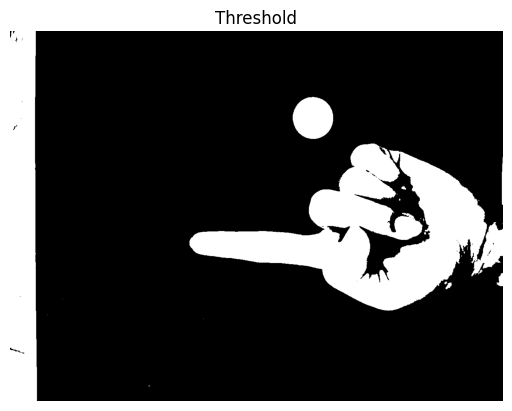

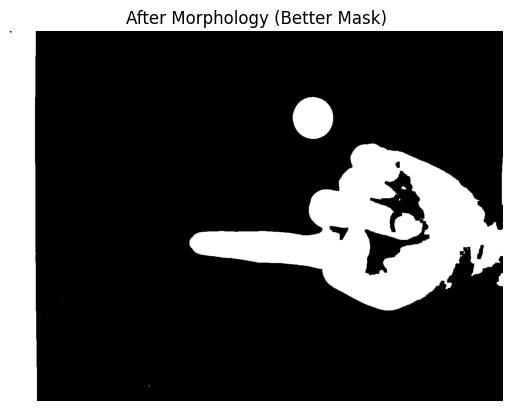

In [5]:
# threshold untuk pisahkan tangan dari background
_, thresh = cv2.threshold(gray, 125, 255, cv2.THRESH_BINARY)

show(thresh, "Threshold")

# morphology untuk bersihkan noise
kernel = np.ones((7,7), np.uint8)
closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

show(closed, "After Morphology (Better Mask)")

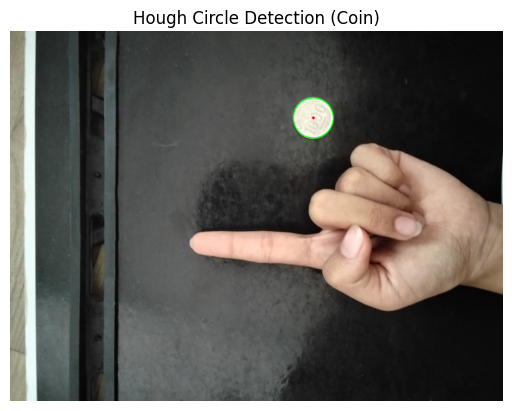

Diameter koin (pixel): 104


In [6]:
# Gunakan gambar grayscale + blur (lebih stabil)
img_blur = cv2.GaussianBlur(gray, (9, 9), 2)

circles = cv2.HoughCircles(
    img_blur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=100,
    param1=100,
    param2=30,
    minRadius=20,
    maxRadius=200
)

circle_img = img_rgb.copy()

coin_diameter_pixel = None

if circles is not None:
    circles = np.uint16(np.around(circles))
    
    for i in circles[0, :]:
        x, y, r = i
        
        # gambar lingkaran
        cv2.circle(circle_img, (x, y), r, (0,255,0), 2)
        cv2.circle(circle_img, (x, y), 2, (255,0,0), 3)

        # ambil lingkaran pertama sebagai koin
        coin_diameter_pixel = 2 * r
        break

show(circle_img, "Hough Circle Detection (Coin)")

print("Diameter koin (pixel):", coin_diameter_pixel)

Area: 2.0
Area: 0.0
Area: 0.0
Area: 0.0
Area: 323.5
Area: 8.0
Area: 0.0
Area: 191.5
Area: 165706.0
Area: 8838.0
Area: 63053.0


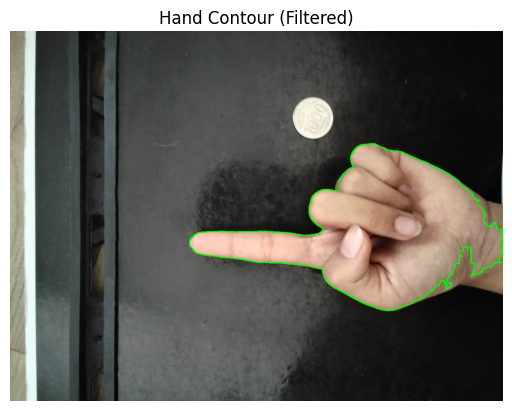

In [7]:
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

candidates = []

for cnt in contours:
    area = cv2.contourArea(cnt)
    
    print("Area:", area)

    if area > 2000:  # buang koin & noise
        candidates.append(cnt)

if len(candidates) == 0:
    raise ValueError("Tidak ada kontur tangan")

# ambil terbesar dari kandidat besar
largest_contour = max(candidates, key=cv2.contourArea)

contour_img = img_rgb.copy()
cv2.drawContours(contour_img, [largest_contour], -1, (0,255,0), 2)

show(contour_img, "Hand Contour (Filtered)")

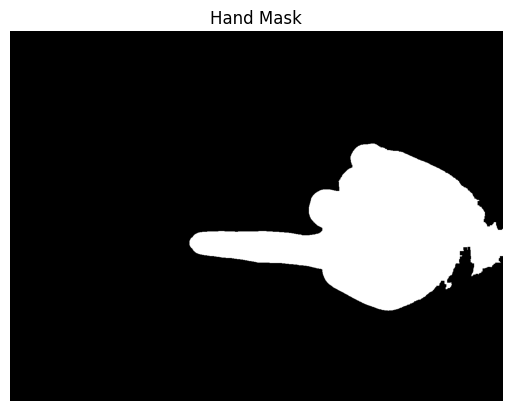

In [8]:
mask = np.zeros_like(gray)

cv2.drawContours(mask, [largest_contour], -1, 255, -1)

show(mask, "Hand Mask")

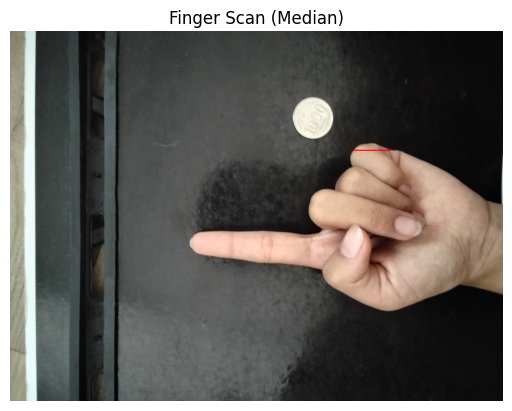

Semua kandidat width: [np.int64(41), np.int64(45), np.int64(48), np.int64(53), np.int64(55), np.int64(59), np.int64(61), np.int64(69), np.int64(73), np.int64(76), np.int64(77), np.int64(82), np.int64(84), np.int64(84), np.int64(94), np.int64(101), np.int64(117), np.int64(119), np.int64(125), np.int64(129), np.int64(132), np.int64(135), np.int64(136), np.int64(140), np.int64(143), np.int64(146), np.int64(148), np.int64(124)]
Lebar jari (median pixel): 89


In [9]:
h, w = mask.shape

widths = []
positions = []

# scan banyak baris
for y in range(int(h*0.3), int(h*0.7)):
    row = mask[y]
    white_pixels = np.where(row == 255)[0]

    if len(white_pixels) < 20:
        continue

    left = white_pixels[0]

    # fokus area kiri (jari)
    region = white_pixels[white_pixels < (left + 200)]

    if len(region) < 10:
        continue

    left = region[0]
    right = region[-1]
    width = right - left

    # filter width realistis
    if 40 < width < 150:
        widths.append(width)
        positions.append((y, left, right))

# validasi
if len(widths) == 0:
    raise ValueError("Tidak ada kandidat lebar jari")

# ambil median (lebih stabil dari average)
finger_width_pixel = int(np.median(widths))

# ambil posisi representatif (tengah list)
mid_index = len(positions) // 2
y, left, right = positions[mid_index]

# visualisasi
scan_img = img_rgb.copy()
cv2.line(scan_img, (left, y), (right, y), (255,0,0), 2)

show(scan_img, "Finger Scan (Median)")

print("Semua kandidat width:", widths)
print("Lebar jari (median pixel):", finger_width_pixel)

In [10]:
REAL_COIN_DIAMETER_CM = 2.4  # Rp1000

cm_per_pixel = REAL_COIN_DIAMETER_CM / coin_diameter_pixel

finger_width_cm = finger_width_pixel * cm_per_pixel

print("cm per pixel:", cm_per_pixel)
print("Lebar jari (cm):", finger_width_cm)

cm per pixel: 0.023076923076923075
Lebar jari (cm): 2.0538461538461537


In [11]:
diameter_mm = finger_width_cm * 10

print("Diameter jari (mm):", round(diameter_mm, 2))

Diameter jari (mm): 20.54


In [12]:
# tabel ukuran cincin (diameter dalam mm)
ring_sizes = {
    4: 14.1,
    5: 14.9,
    6: 15.7,
    7: 16.5,
    8: 17.3,
    9: 18.1,
    10: 19.0,
    11: 19.8,
    12: 20.6,
    13: 21.4,
    14: 22.2
}

# cari size terdekat
def get_ring_size(diameter_mm):
    closest_size = None
    min_diff = float('inf')

    for size, d in ring_sizes.items():
        diff = abs(diameter_mm - d)

        if diff < min_diff:
            min_diff = diff
            closest_size = size

    return closest_size, ring_sizes[closest_size]


size, ref_diameter = get_ring_size(diameter_mm)

print("Diameter hasil (mm):", round(diameter_mm, 2))
print("Ukuran cincin (Indonesia):", size)
print("Diameter referensi size (mm):", ref_diameter)
print("Selisih (error):", round(abs(diameter_mm - ref_diameter), 2), "mm")

if diameter_mm < 14 or diameter_mm > 22:
    print("⚠️ Warning: Diameter di luar range normal manusia")

Diameter hasil (mm): 20.54
Ukuran cincin (Indonesia): 12
Diameter referensi size (mm): 20.6
Selisih (error): 0.06 mm
